In [90]:
import pandas as pd
import numpy as np
import altair as alt

## Cleaning Text 

Given the below example data, clean it up in the following ways:

1. Replace the British spellings ('yoghurt' and 'flavour') with the American spellings ('yogurt' and 'flavor'), in one line. 
2. Identify the rows that contain the word "mixed". 
3. Use a regular expression to extract the words that come before "mixed". Hint: look at the group constructs in the regex101 quick reference. 
4. Use a split to get the second sentence in a string. Then, fuzzy match to get the correct spelling of Dwight's name. 

In [111]:
names = ['Jim','Pam','Dwight']
mystrings = pd.Series(["You are the worst assistant ever and you're disgusting. Dwigt.",
                 "Pam's favorite flavour of yoghurt, which is mixed berry.",
                 "Jim said mixed berries? Oh, well, yeah he's on to me."])

In [113]:
mystrings.str.replace('flavour', 'flavor').str.replace('yoghurt', 'yogurt')



0    You are the worst assistant ever and you're di...
1    Pam's favorite flavor of yogurt, which is mixe...
2    Jim said mixed berries? Oh, well, yeah he's on...
dtype: object

## Text Analysis

#### Step 1: Use the string manipulation you just learned remove the spaces and apostrophes in the column names in the following dataset.

In [116]:
pets = pd.read_csv('seattle_pet_licenses.csv').dropna(subset = ["Animal's Name"])
pets.columns = pets.columns.str.replace(" ","").str.replace("'","")
pets.head()


,AnimalsName,LicenseIssueDate,LicenseNumber,PrimaryBreed,SecondaryBreed,Species,ZIPCode
0,Ozzy,2005-03-29T00:00:00.000,130651.0,"Dachshund, Standard Smooth Haired",NaN,Dog,98104
1,Jack,2009-12-23T00:00:00.000,898148.0,"Schnauzer, Miniature","Terrier, Rat",Dog,98107
2,Ginger,2006-01-20T00:00:00.000,29654.0,"Retriever, Golden","Retriever, Labrador",Dog,98117
3,Pepper,2006-02-07T00:00:00.000,75432.0,Manx,Mix,Cat,98103
4,Addy,2006-08-04T00:00:00.000,729899.0,"Retriever, Golden",NaN,Dog,98105


#### Step 2: Explore the Data
- How many unique names are there? 
- Are there similar names that are spelled differently?    
- How many names does each pet have? Is there a pattern you can pull out from that? 
- Do any names stand out to you?
- Could there be any relationships between names and breeds, species, or zip codes?

**Leave all your exploration steps here to show what you looked at.**

In [276]:
UniqueNames = pets['AnimalsName'].str.lower().str.strip().unique()
UniqueNames.shape

(15621,)

There are total 15621 unique names.

In [122]:
from rapidfuzz import fuzz

names = pets['AnimalsName'].str.lower().str.strip().unique()

similar_pairs = []

for i in range(len(names)):
    for j in range(i+1, len(names)):
        if fuzz.ratio(names[i], names[j]) >= 90:
            similar_pairs.append((names[i], names[j]))

len(similar_pairs)


1882

First all the animal names are converted into lower case,removed all leading and trailing whitespace characters. Then checked the total unique names in the data which turned out to be 15621. \
To see if any names are spelled differently but are similar names i applied fuzzy nmatching. I compared each name pair and looked for similarity scores above 90. Then there were total 1882 appears to be similar.

In [128]:
pets['NameWordCount'] = pets['AnimalsName'].str.split().str.len()
pets['NameWordCount'].value_counts()

NameWordCount
1    60555
2     3681
3      377
4       46
5       12
0        8
6        3
7        2
8        1
Name: count, dtype: int64

To check how many names does each pet has i used str.split and check the length of the list. Based on this we can see although there are more number of pets with single name, but there are multple names for several other pets.

In [285]:
#identify the most common first name used when a pet has two-word names
pets['NameWordCount'] = pets['AnimalsName'].str.split().str.len()
two_word_names = pets[pets['NameWordCount'] == 2]
two_word_names['FirstWord'] = two_word_names['AnimalsName'].str.split().str[0].str.lower().str.strip()
first_word_counts = two_word_names['FirstWord'].value_counts().reset_index()
first_word_counts.columns = ['word', 'count']
first_word_counts.head(10)

/var/folders/y4/fkn560k16c3__twnyy0m4jxr0000gn/T/ipykernel_53630/2387626859.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  two_word_names['FirstWord'] = two_word_names['AnimalsName'].str.split().str[0].str.lower().str.strip()


,word,count
0,little,78
1,miss,69
2,mr.,69
3,mr,67
4,baby,35
5,maggie,30
6,lady,30
7,lucy,29
8,big,29
9,sweet,27


There are multiple names for each pet. The common first names are Little, Miss, Mr. , mr for pets having 2 names.

In [287]:
name_species_groups = pets.groupby('AnimalsName')['Species'].nunique()

# Names used in 3 species
common_names = name_species_groups[name_species_groups == 3].index

# Filter the rows containing only common names
common_name_rows = pets[pets['AnimalsName'].isin(common_names)]

common_name_species_freq = (
    common_name_rows.groupby(['AnimalsName', 'Species'])
    .size()
    .reset_index(name='Count')
)
# Count frequency of each common name
common_name_freq = common_name_rows['AnimalsName'].value_counts()
common_name_freq


AnimalsName
Molly        310
Daisy        300
Rosie        196
Olive        181
Roxy         122
Teddy        115
Millie        98
Fiona         58
Holly         53
Sugar         42
Sassy         40
Mojo          39
Heidi         37
Basil         35
Cinnamon      27
Atticus       21
Darla         18
Lenny         16
Spud          15
Nani          15
Eloise        15
Arya          14
Darcy         14
Priscilla     11
Spice         11
Junebug        7
Truffle        7
Mugsy          5
Alley          5
Amanda         4
Name: count, dtype: int64

There are some pet names that are shared across different species (e.g., both dogs, cats, livestock named “Molly”, “Daisy”, "Arya",etc.).

In [291]:
breed_species_groups = pets.groupby('PrimaryBreed')['Species'].nunique()

# Breeds assigned to more than one species
breeds_across_species = breed_species_groups[breed_species_groups > 1]
breeds_across_species


PrimaryBreed
Mix    2
Name: Species, dtype: int64

There is one primary breed Mix which appears both under cat and dog. This probably refers to a cross breed.

In [294]:
# Assuming your dataframe is called `pets` and has a column 'ZIPCode'
zip_counts = (
    pets.groupby('ZIPCode')
        .size()
        .reset_index(name='pet_count')
        .sort_values(by='pet_count', ascending=False)
)

zip_counts.head()

,ZIPCode,pet_count
86,98115,5825
69,98103,5492
90,98117,4911
108,98125,3721
75,98107,3056


I looked at total number of pets for each pincode. The area with pincode 98115 has highest number of pets which includes all the three species in the dataset.

#### Step 3: Come up with a question/goal
Pick 3 interesting name patterns that you found in your exploration above. 
- How could you visualize these patterns? 
- What marks and encodings would work well for these visualization? 
- Is there any external data that would be useful?
- What text manipulation will you have to do before attempting to plot the data? 

Q1 - Most common first names in the pets having two names.\
Q2 - There are few names which are common across three different species.\
Q3 - Visaulizing total number of pets for each pin code in the seattle area\

### Q1: Most common first names in the pets having two names.


- I would like to visualize this pattern using a word cloud, which displays the most common first words (prefixes) among pets with two-word names. A word cloud is effective here because it emphasizes the most frequently used prefixes through larger and bolder text, making naming trends such as “mr”, “miss”, “baby”, or “princess” immediately visible.

- A word cloud uses text marks, where font size encodes frequency: larger words indicate more pets with that prefix. Color can be used to highlight different categories, but size is the primary meaningful encoding. External data is not strictly necessary for this visualization.

- Before generating the word cloud, I cleaned the name strings by lowercasing them, trimming whitespace, and splitting each name into words. I extracted only the first word of each two-word name and counted its frequency to prepare the input for the visualization.

### Q2: Top 10 Most Frequent Names Shared Across All 3 Species

- I think this question can be better answered using a bar plot, which is ideal for comparing the top 10 most frequent names that appear across all three species (Dog, Cat, and livestock). A bar plot clearly shows which names are used the most often, making cross-species naming patterns easy to interpret.
- A bar mark works best here. The x-axis encodes the total count of each shared name, while the y-axis lists the names, sorted from most to least frequent.
- External data is not essential for this plot. However, species population distribution or breed popularity by region could provide additional context for why certain names are consistently used across species.

- I normalized the names by converting them to lowercase and trimming whitespace. Then, I grouped by name and counted the number of species in which each name appears. Only names present in all three species were selected. Finally, I computed total counts across species and selected the top 10 for visualization.

### Q3: Total Number of Pets by ZIP Code in Seattle

- This question can be better visualized using a choropleth map, where each ZIP code in Seattle is represented as a polygon, and the color intensity corresponds to the total number of pets registered in that ZIP code. This geographic visualization makes it easy to identify areas with high or low pet density.

- A choropleth uses geoshape marks, where polygon boundaries represent ZIP code regions. The color encoding represents the pet count, typically using a sequential color scale (e.g., light to dark blue). Tooltips provide additional detail when hovering over each ZIP code.

- This visualization requires external geographic data, specifically a ZIP-code GeoJSON file containing Seattle ZIP boundaries. I used the GeoJSON file from:
https://raw.githubusercontent.com/seattleio/seattle-boundaries-data/master/data/zip-codes.geojson
This file provides the polygon geometries needed to draw each ZIP code region.

- I aggregated the number of pets per ZIP code. I joined the aggregated counts to the GeoJSON data using the ZIP code property (ZCTA5CE10) before plotting.

#### Step 4: Make visualizations
Code up some visualizations for the 3 questions in Step 3. Make sure to revisit your questions, ensure the visualization addresses them effectively, and iterate through the EDA process. Ensure that all your plots here are labeled appropriately. 

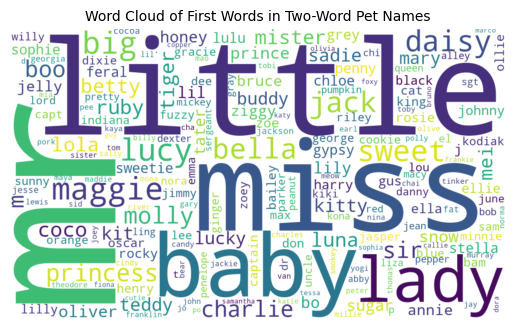

In [308]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# combine all first words into one string
text = " ".join(two_word_names['FirstWord'])

# create the word cloud
wc = WordCloud(
    width=1200,
    height=700,
    background_color='white',
    colormap='viridis'
).generate(text)

plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of First Words in Two-Word Pet Names", fontsize=10)
plt.show()


In [237]:
pets['Name_clean'] = pets['AnimalsName'].str.lower().str.strip()

# Count species per name
name_species_groups = pets.groupby('Name_clean')['Species'].nunique()

# Names that appear in all 3 species
common_names = name_species_groups[name_species_groups == 3].index

# Filter dataset to only those
common_df = pets[pets['Name_clean'].isin(common_names)]

# Count total frequencies across species
common_freq = common_df['Name_clean'].value_counts().reset_index()
common_freq.columns = ['Name', 'Count']
top5_common = common_freq.head(10)

alt.Chart(top5_common).mark_bar(color="#76b5c5").encode(
    x=alt.X('Count:Q', title='Total Count Across All Species'),
    y=alt.Y('Name:N', sort='-x', title='Pet Name'),
    tooltip=['Name', 'Count']
).properties(
    width=450,
    height=300,
    title='Top 10 Most Frequent Common Names Across All 3 Species'
)


/opt/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

In [245]:
import pandas as pd

# Assuming your dataframe is called `pets` and has a column 'ZIPCode'
zip_counts = (
    pets.groupby('ZIPCode')
        .size()
        .reset_index(name='pet_count')
)
zip_counts['ZIPCode'] = zip_counts['ZIPCode'].astype(str)

geo_url = "https://raw.githubusercontent.com/seattleio/seattle-boundaries-data/refs/heads/master/data/zip-codes.geojson"

choropleth = (
    alt.Chart(
        alt.Data(
            url=geo_url,
            format=alt.DataFormat(type='json', property='features')
        )
    )
    .mark_geoshape(stroke='black', strokeWidth=0.5)
    .encode(
        color=alt.Color(
            'pet_count:Q',
            title='Number of Pets',
            scale=alt.Scale(scheme='blues')
        ),
        tooltip=[
            alt.Tooltip('properties.ZCTA5CE10:N', title='ZIP Code'),
            alt.Tooltip('pet_count:Q', title='Total Pets')
        ]
    )
    .transform_lookup(
        lookup='properties.ZCTA5CE10',
        from_=alt.LookupData(
            zip_counts,
            key='ZIPCode',
            fields=['pet_count']
        )
    )
    .properties(
        width=500,
        height=600,
        title='Total Number of Pets per ZIP Code – Seattle'
    )
    .project(type='mercator')
)

choropleth



/opt/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/opt/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/opt/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

In [241]:
import json
import urllib.request

url = "https://raw.githubusercontent.com/seattleio/seattle-boundaries-data/refs/heads/master/data/zip-codes.geojson"

with urllib.request.urlopen(url) as resp:
    zip_geojson = json.loads(resp.read().decode())

zip_geojson['features'][0]['properties']


{'ZCTA5CE10': '98136',
 'AFFGEOID10': '8600000US98136',
 'GEOID10': '98136',
 'ALAND10': 5954030.0,
 'AWATER10': 2163632.0}

#### Final: Bad Text

Take the plot that you find the most interesting and recreate it here. Rather than making the text (title, labels, caption, etc) excellent, make it exceptionally **bad** (keeping it reasonable/readable). Below your graphic, write a description of why the designs and language is a poor choice. 

In [347]:

import pandas as pd

zip_counts = (
    pets.groupby('ZIPCode')
        .size()
        .reset_index(name='pet_count')
)
zip_counts['ZIPCode'] = zip_counts['ZIPCode'].astype(str)

geo_url = "https://raw.githubusercontent.com/seattleio/seattle-boundaries-data/refs/heads/master/data/zip-codes.geojson"

choropleth = (
    alt.Chart(
        alt.Data(
            url=geo_url,
            format=alt.DataFormat(type='json', property='features')
        )
    )
    .mark_geoshape(stroke='white', strokeWidth=0.5)
    .encode(
        color=alt.Color(
            'pet_count:Q',
            title='Number of Pets',
            scale=alt.Scale(scheme='rainbow')
        ),
        tooltip=[
            alt.Tooltip('properties.ZCTA5CE10:N', title='ZIP Code'),
            alt.Tooltip('pet_count:Q', title='Total Pets')
        ]
    )
    .transform_lookup(
        lookup='properties.ZCTA5CE10',
        from_=alt.LookupData(
            zip_counts,
            key='ZIPCode',
            fields=['pet_count']
        )
    )
    .properties(
        width=500,
        height=600,
        title='Total Number of Pets per ZIP Code – Seattle'
    )
    .project(type='equirectangular')
)

choropleth




/opt/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/opt/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/opt/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

The above visualization has some flaws that make it confusing, misleading, and difficult to interpret. First, the use of an inappropriate color scheme (such as rainbow or highly saturated colors) creates visual noise and does not meaningfully encode quantitative differences. Sequential numeric data requires a smooth, ordered color scale, and using arbitrary colors breaks the ability to accurately compare ZIP code values. In addition, the map projection here is equirectangular which is poorly chosen using a national-level projection for a city map results in distortion that misrepresents the geographic layout of Seattle.